# jOtter feature showcase 🦦

Run this top to bottom with **Ctrl+r** (run all — cells queue as `In [·]` and flip to `In [*]` when they start), or step through with **Shift+Enter**. Press **?** for the key cheatsheet.

Some features live outside cells — try them while you're here:

| feature | how to try it |
|---------|---------------|
| search | `/` then type `spinner`, Enter; `n` / `N` cycle matches |
| goto | `5G` jumps to cell 5, `3j` moves down 3 |
| undo cell ops | `dd` a cell, then `u`; also works for moves (`J`/`K`) and `m` |
| quit safety | edit something, press `q`: save / discard / cancel prompt |
| external changes | touch the file in another shell, `w` refuses, `W` forces |
| autosave | edit, wait 30 s, see `.showcase.ipynb.autosave` appear |

## Markdown rendering

Inline: **bold**, *italic*, `code`, math $e^{i\pi} + 1 = 0$, and a [link to the repo](https://github.com/samox/jotter).

- bullets
- with a nested dollar $\tau$ mid-sentence

| stage | feature | status |
|-------|---------|--------|
| 1 | stream semantics | done |
| 2 | tables, links, emphasis | done |

Display math:

$$G(\mathbf{k}, \tau) = -\langle T_\tau\, c_{\mathbf{k}}(\tau)\, c^\dagger_{\mathbf{k}}(0) \rangle$$

A local image (path relative to the notebook):

![jotter screenshot](assets/showcase.png)

In [1]:
# Long outputs: chunks coalesce into ONE output, display becomes a viewport
# pinned to the tail. Wheel over it or use [ ] to scroll, o to collapse.
import time
for i in range(1, 41):
    print(f"line {i:3d} — the viewport follows the tail while this streams")
    time.sleep(0.1)

line   1 — the viewport follows the tail while this streams
line   2 — the viewport follows the tail while this streams
line   3 — the viewport follows the tail while this streams
line   4 — the viewport follows the tail while this streams
line   5 — the viewport follows the tail while this streams
line   6 — the viewport follows the tail while this streams
line   7 — the viewport follows the tail while this streams
line   8 — the viewport follows the tail while this streams
line   9 — the viewport follows the tail while this streams
line  10 — the viewport follows the tail while this streams
line  11 — the viewport follows the tail while this streams
line  12 — the viewport follows the tail while this streams
line  13 — the viewport follows the tail while this streams
line  14 — the viewport follows the tail while this streams
line  15 — the viewport follows the tail while this streams
line  16 — the viewport follows the tail while this streams
line  17 — the viewport follows the tail

In [2]:
# \r overwrites in place: one line on screen, in memory, and in the saved file
import time
for i in range(1, 41):
    print(f"line {i:3d}")
    time.sleep(0.1)
#for i in range(101):
#    print(f"progress [{'#' * (i // 5):<20}] {i:3d}%", end="\r", flush=True)
#    time.sleep(0.02)
#print()
#print("done — a single line survived")

line   1
line   2
line   3
line   4
line   5
line   6
line   7
line   8
line   9
line  10
line  11
line  12
line  13
line  14
line  15
line  16
line  17
line  18
line  19
line  20
line  21
line  22
line  23
line  24
line  25
line  26
line  27
line  28
line  29
line  30
line  31
line  32
line  33
line  34
line  35
line  36
line  37
line  38
line  39
line  40


In [11]:
# clear_output(wait=True): flicker-free replacement instead of endless append
import time
from IPython.display import clear_output
for frame in ["◐", "◓", "◑", "◒"] * 5:
    clear_output(wait=True)
    print(f"spinner {frame}")
    time.sleep(0.1)
clear_output(wait=True)
print("spinner done — replaced, never appended")

spinner done — replaced, never appended


In [4]:
# tqdm combines \r and stderr streams — stays a single tidy line
try:
    import time
    from tqdm import trange
    for _ in trange(60, desc="tqdm"):
        time.sleep(0.02)
except ImportError:
    print("tqdm not installed — skipped")

tqdm: 100%|██████████| 60/60 [00:01<00:00, 49.20it/s]


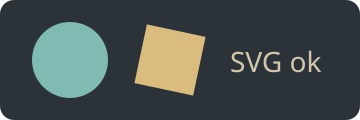

In [5]:
# image/svg+xml outputs render via resvg
from IPython.display import SVG
SVG('''<svg xmlns="http://www.w3.org/2000/svg" width="360" height="120">
  <rect width="360" height="120" rx="14" fill="#2b3339"/>
  <circle cx="70" cy="60" r="38" fill="#7fbbb3"/>
  <rect x="140" y="30" width="60" height="60" fill="#dbbc7f" transform="rotate(12 170 60)"/>
  <text x="230" y="72" font-size="28" fill="#d3c6aa" font-family="sans-serif">SVG ok</text>
</svg>''')

In [6]:
# text/markdown outputs go through the markdown renderer
from IPython.display import Markdown
Markdown(
    "**markdown output** with a [link](https://jupyter.org) and math $E = \\hbar\\omega$\n\n"
    "| mime | rendered |\n|------|----------|\n| text/markdown | yes |"
)

**markdown output** with a [link](https://jupyter.org) and math $E = \hbar\omega$

| mime | rendered |
|------|----------|
| text/markdown | yes |

In [7]:
# an output with no renderable rep names what it carries instead of vanishing
from IPython.display import display
display({"text/html": "<b>html only</b>"}, raw=True)

html only

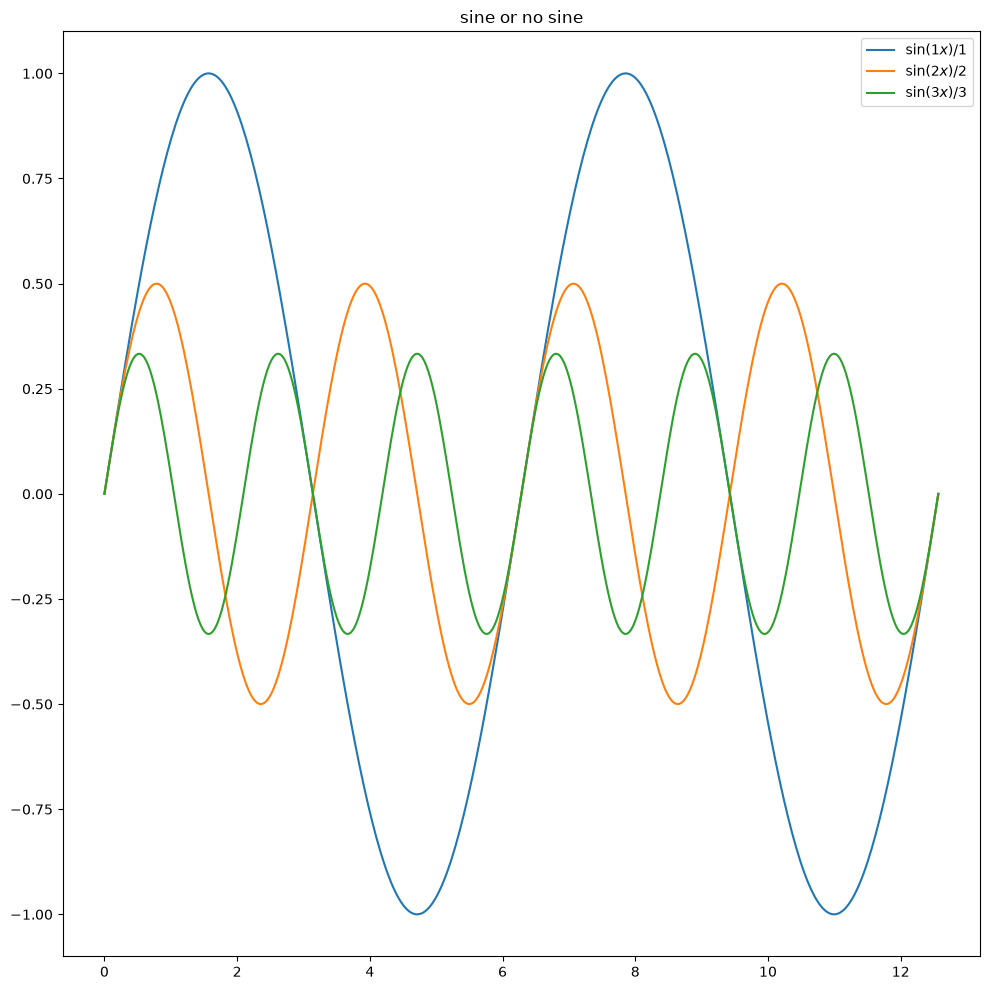

In [8]:
# plots: one Lanczos prescale to <=18 rows, transmitted once, cropped (never
# rescaled) at the viewport edges — scroll this across the top and bottom
import numpy as np
import os
import matplotlib.pyplot as plt
x = np.linspace(0, 4 * np.pi, 400)
plt.subplots(figsize=(10, 10))
for k in range(1, 4):
    plt.plot(x, np.sin(k * x) / k, label=f"$\\sin({k}x)/{k}$")
plt.legend(); plt.title("sine or no sine")
plt.tight_layout(); plt.show()

In [9]:
# input() prompts in the status line (Esc sends empty, Ctrl+C interrupts)
name = input("your name: ")
print(f"hello, {name or 'stranger'}!")

hello, Sam!


In [10]:
# ANSI tracebacks render colored; run-all stops queued cells here (aborted
# cells drop back from In [·] to idle)
def boom(depth=3):
    if depth == 0:
        raise ValueError("ANSI traceback demo — everything above still ran")
    return boom(depth - 1)
boom()

ValueError: ANSI traceback demo — everything above still ran

In [ ]:
# with stop_on_error, run-all aborts here — run it by hand to prove the
# kernel survived the traceback above
print("still alive")